<h2>Food Recipe Website Scrape 1</h2>

<h3>Contents</h3>
<ul>
    <li><a href='#intro'>Introduction</a></li>
    <li><a href='#testing'>Testing</a></li>
    <li><a href='#code'>Scrapcode</a></li>
    <li><a href='#analysis'>Analysis</a></li>
</ul>


<h3>Introduction</h3>
<a id='intro'></a>

<p>To be added</p>

In [2]:
#importing necessary packages

from bs4 import BeautifulSoup
import lxml
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("packages imported successfully")

packages imported successfully


In [3]:
#assigning site to a variable
website = "https://www.bbcgoodfood.com"
websiteSearchPattern = "https://www.bbcgoodfood.com/search?q="

### Testing Section
<a id='testing'></a>
<p>This section primarily looks at testing what can be scraped from the website. Different aspects of the site will be scraped to see how they are done before proceeding to write the whole code to scrape multiple items from the site.</p>

In [4]:
#use requests package to get html content of the site and parse it in beautifulsoup with lxml
site_request = requests.get(websiteSearchPattern+"chicken")
site_soup = BeautifulSoup(site_request.text,'lxml')

#writing contents to a file
with open('Site content.txt','w') as file:
    file.write(site_soup.prettify())
    file.close()

In [5]:
#searching content for search results
recipes = site_soup.find_all('article')

Getting information from the first result

In [6]:
firstRecipe = recipes[0]

#getting name of recipe
recipeName = firstRecipe.find('h2',class_='heading-4').text

#getting the ratings
recipeRating = firstRecipe.find(class_='sr-only').text.split()[4]
reciptRatingCount = firstRecipe.find(class_='rating__count-text body-copy-small').text.split()[0]

print(f"The name of the recipe is {recipeName} and it has been rated up to {reciptRatingCount} times to obtain a rating of {recipeRating} out of 5")

The name of the recipe is Chicken & chorizo jambalaya and it has been rated up to 2675 times to obtain a rating of 4.8 out of 5


In [7]:
#get recipe link

recipeLink = firstRecipe.find(class_='card__section card__media').a['href']
print("Link for recipe is " + recipeLink)

recipeSite = requests.get(website+recipeLink)
recipeSoup = BeautifulSoup(recipeSite.text,'lxml')

Link for recipe is /recipes/chicken-chorizo-jambalaya


In [8]:
#information from recipe link

recipePrepTime = int(recipeSoup.find_all('time')[0].text.split()[0])
recipeCookTime = int(recipeSoup.find_all('time')[1].text.split()[0])

print("Prep time: "+ str(recipePrepTime))
print("Cooking time: " + str(recipeCookTime))
print("Total time: " + str(recipePrepTime+recipeCookTime))

Prep time: 10
Cooking time: 45
Total time: 55


In [9]:
#get and store recipe image
recipeImg = recipeSoup.find(class_='post recipe').find('img', class_='image__img')['src']
ImgContent = requests.get(recipeImg).content

with open(recipeName+".png",'wb') as file:
    file.write(ImgContent)
    file.close()

In [10]:
recipeSoup.find_all('td')

[<td class="key-value-blocks__prefix"></td>,
 <td class="key-value-blocks__key">kcal</td>,
 <td class="key-value-blocks__value">445</td>,
 <td class="key-value-blocks__prefix"></td>,
 <td class="key-value-blocks__key">fat</td>,
 <td class="key-value-blocks__value">10<!-- -->g</td>,
 <td class="key-value-blocks__prefix"></td>,
 <td class="key-value-blocks__key">saturates</td>,
 <td class="key-value-blocks__value">3<!-- -->g</td>,
 <td class="key-value-blocks__prefix"></td>,
 <td class="key-value-blocks__key">carbs</td>,
 <td class="key-value-blocks__value">64<!-- -->g</td>,
 <td class="key-value-blocks__prefix"></td>,
 <td class="key-value-blocks__key">sugars</td>,
 <td class="key-value-blocks__value">7<!-- -->g</td>,
 <td class="key-value-blocks__prefix"></td>,
 <td class="key-value-blocks__key">fibre</td>,
 <td class="key-value-blocks__value">2<!-- -->g</td>,
 <td class="key-value-blocks__prefix"></td>,
 <td class="key-value-blocks__key">protein</td>,
 <td class="key-value-blocks__val

In [11]:
test = recipeSoup.find_all('td')
print("number of items: "+str(len(test)))
for row in test:
    if row.text == 'kcal':
        print(row.find_next('td').text)



number of items: 24
445


### ScarpCode <a id='code'></a>

<p>The code that will be written will be making use of the search pattern by rating and will only scrape the first page as it contains 30 results</p>

>**Different Search Patterns**: Below are searching patterns that can be used to get results in different ways
><li>By Rating: https://www.bbcgoodfood.com/search?q=chicken&tab=recipe&sort=rating</li>
><li>By Relevance: https://www.bbcgoodfood.com/search?q=chicken&tab=recipe&sort=relevant</li>
><li>By Fastest Cook time: https://www.bbcgoodfood.com/search?q=chicken&tab=recipe&sort=quickest</li>
><li>By Latest added: https://www.bbcgoodfood.com/search?q=chicken&tab=recipe&sort=published</li>

In [12]:
'''
For this code, the search pattern used will be By Rating and only the first page will be scraped which should be the most rated foods
on the platform. The code will start by requesting \for a food to search for and the results will be stored in a dictionary which will later on
be converted to a datatable using pandas.
'''
website = "https://www.bbcgoodfood.com"
#search = input("Enter a meal/dish you want to search for: ")
search = 'chicken'
websiteSearchPattern = f'https://www.bbcgoodfood.com/search?q={search}&tab=recipe&sort=rating'

#defining the dictionary
ScrapeResults = {}

site_request = requests.get(websiteSearchPattern)
site_soup = BeautifulSoup(site_request.text,'lxml')


recipes_results = site_soup.find_all('article')

#print("The result type is "+ str(type(recipes_results)) +"\n The number of results is " + str(len(recipes_results)))

count = 1
#looping through all the results
for index,recipe in enumerate(recipes_results):

    try:
        innerResult = {}

        #print("Looking at recipe " + str(index))
        print("Looking at recipe " + str(count))
        innerResult["Name"] = recipe.find('h2',class_='heading-4').text
        innerResult["Rating"] = recipe.find(class_='sr-only').text.split()[4]
        innerResult["Review Count"] = recipe.find(class_='rating__count-text body-copy-small').text.split()[0]

        innerResult["link"] = website+recipe.find(class_='card__section card__media').a['href']
        print("Link for recipe is " + innerResult["link"])

        #dive into each recipe
        print('getting more information for recipe unique link')
        recipeSite = requests.get(innerResult["link"])
        recipeSoup = BeautifulSoup(recipeSite.text,'lxml')
        
        if len(recipeSoup.find_all('time')) > 1:
            print("Continue with search")
            innerResult["Prep time"] = int(recipeSoup.find_all('time')[0].text.split()[0])
            innerResult["Cooking time"] = int(recipeSoup.find_all('time')[1].text.split()[0])
            innerResult["Total time"] = innerResult["Prep time"] + innerResult["Cooking time"]
        else:
            print("different format encountered")
            innerResult["Total time"] = int(recipeSoup.find_all('time')[0].text.split()[0])
    


        tablesearch = recipeSoup.find_all('td')
        print("number of items: "+str(len(tablesearch)))
        for row in tablesearch:
            if row.text == 'kcal':
                value = row.find_next('td').text
                print("number of calories is " + value + "kcal")
                innerResult["kcal"] = int(value)
            elif row.text == 'fat':
                value = row.find_next('td').text.replace("g",'')
                print("number of fats is " + value + "kcal")
                innerResult["fats"] = int(value)
            elif row.text == 'carbs':
                value = row.find_next('td').text.replace("g","")
                innerResult["carbs"] = int(value)
            elif row.text == 'protein':
                value = row.find_next('td').text.replace("g","")
                innerResult["proteins"] = int(value)

        ScrapeResults[index] = innerResult
        count += 1

    except:
        print("Exception occurred as item is not a recipe card")

Looking at recipe 1
Link for recipe is https://www.bbcgoodfood.com/recipes/chicken-chorizo-jambalaya
getting more information for recipe unique link
Continue with search
number of items: 24
number of calories is 445kcal
number of fats is 10kcal
Looking at recipe 2
Link for recipe is https://www.bbcgoodfood.com/recipes/red-lentil-chickpea-chilli-soup
getting more information for recipe unique link
Continue with search
number of items: 24
number of calories is 222kcal
number of fats is 5kcal
Looking at recipe 3
Link for recipe is https://www.bbcgoodfood.com/recipes/chicken-noodle-soup
getting more information for recipe unique link
Continue with search
number of items: 24
number of calories is 217kcal
number of fats is 2kcal
Looking at recipe 4
Link for recipe is https://www.bbcgoodfood.com/recipes/home-style-chicken-curry
getting more information for recipe unique link
Continue with search
number of items: 24
number of calories is 382kcal
number of fats is 17.7kcal
Exception occurred as

In [13]:
ScrapeResults

{0: {'Name': 'Chicken & chorizo jambalaya',
  'Rating': '4.8',
  'Review Count': '2675',
  'link': 'https://www.bbcgoodfood.com/recipes/chicken-chorizo-jambalaya',
  'Prep time': 10,
  'Cooking time': 45,
  'Total time': 55,
  'kcal': 445,
  'fats': 10,
  'carbs': 64,
  'proteins': 30},
 1: {'Name': 'Red lentil, chickpea & chilli soup',
  'Rating': '4.8',
  'Review Count': '850',
  'link': 'https://www.bbcgoodfood.com/recipes/red-lentil-chickpea-chilli-soup',
  'Prep time': 10,
  'Cooking time': 25,
  'Total time': 35,
  'kcal': 222,
  'fats': 5,
  'carbs': 33,
  'proteins': 13},
 2: {'Name': 'Chicken noodle soup',
  'Rating': '4.8',
  'Review Count': '794',
  'link': 'https://www.bbcgoodfood.com/recipes/chicken-noodle-soup',
  'Prep time': 10,
  'Cooking time': 30,
  'Total time': 40,
  'kcal': 217,
  'fats': 2,
  'carbs': 26,
  'proteins': 26},
 4: {'Name': 'Chicken biryani',
  'Rating': '4.7',
  'Review Count': '755',
  'link': 'https://www.bbcgoodfood.com/recipes/chicken-biryani',


## Analysis <a id='analysis'></a>

This next section will be making use of pandas library to convert the dictionary into a table and see if any analytics can be done

Read the dictionary into a pandas dataframe

In [14]:
dt = pd.DataFrame.from_dict(ScrapeResults,orient='index')

In [15]:
dt.columns

Index(['Name', 'Rating', 'Review Count', 'link', 'Prep time', 'Cooking time',
       'Total time', 'kcal', 'fats', 'carbs', 'proteins'],
      dtype='object')

In [16]:
dt.dtypes

Name             object
Rating           object
Review Count     object
link             object
Prep time       float64
Cooking time    float64
Total time        int64
kcal              int64
fats              int64
carbs             int64
proteins          int64
dtype: object

In [17]:
dt.head()

,Name,Rating,Review Count,link,Prep time,Cooking time,Total time,kcal,fats,carbs,proteins
0,Chicken & chorizo jambalaya,4.8,2675,https://www.bbcgoodfood.com/recipes/chicken-ch...,10.0,45.0,55,445,10,64,30
1,"Red lentil, chickpea & chilli soup",4.8,850,https://www.bbcgoodfood.com/recipes/red-lentil...,10.0,25.0,35,222,5,33,13
2,Chicken noodle soup,4.8,794,https://www.bbcgoodfood.com/recipes/chicken-no...,10.0,30.0,40,217,2,26,26
4,Chicken biryani,4.7,755,https://www.bbcgoodfood.com/recipes/chicken-bi...,10.0,30.0,40,617,12,83,49
5,Chicken pasta bake,4.7,738,https://www.bbcgoodfood.com/recipes/chicken-pa...,30.0,45.0,75,575,30,41,33


In [18]:
dt.describe()

,Prep time,Cooking time,Total time,kcal,fats,carbs,proteins
count,24.000000,24.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,15.416667,24.791667,38.115385,396.615385,17.269231,31.076923,29.346154
std,8.836272,15.200055,19.119261,176.301577,11.205562,24.885213,14.966475
min,5.000000,1.000000,1.000000,115.000000,2.000000,0.000000,3.000000
25%,10.000000,13.750000,26.250000,252.000000,8.500000,16.000000,16.750000
50%,12.500000,25.000000,40.000000,375.000000,15.000000,24.500000,30.000000
75%,16.250000,36.250000,48.750000,515.750000,20.000000,40.500000,39.500000
max,45.000000,50.000000,75.000000,855.000000,47.000000,91.000000,55.000000


In [19]:
dt.isnull().sum()

Name            0
Rating          0
Review Count    0
link            0
Prep time       2
Cooking time    2
Total time      0
kcal            0
fats            0
carbs           0
proteins        0
dtype: int64

In [20]:
#convert column 
dt['Review Count'] = pd.to_numeric(dt['Review Count'])
dt.dtypes

Name             object
Rating           object
Review Count      int64
link             object
Prep time       float64
Cooking time    float64
Total time        int64
kcal              int64
fats              int64
carbs             int64
proteins          int64
dtype: object

In [21]:
dt2 = dt[dt["Prep time"].isnull() == False]

In [22]:
dt2.isnull().sum()

Name            0
Rating          0
Review Count    0
link            0
Prep time       0
Cooking time    0
Total time      0
kcal            0
fats            0
carbs           0
proteins        0
dtype: int64

In [23]:
dt.duplicated().sum()

0

### Nutrition

Looking at the nutrition of the food gathered from the webscrape job. Comparing the total calories to the different parts of the food (fats, carbs and protein).

Looking to determine which food is best based on certain requirements like low in carbs but high in protein etc

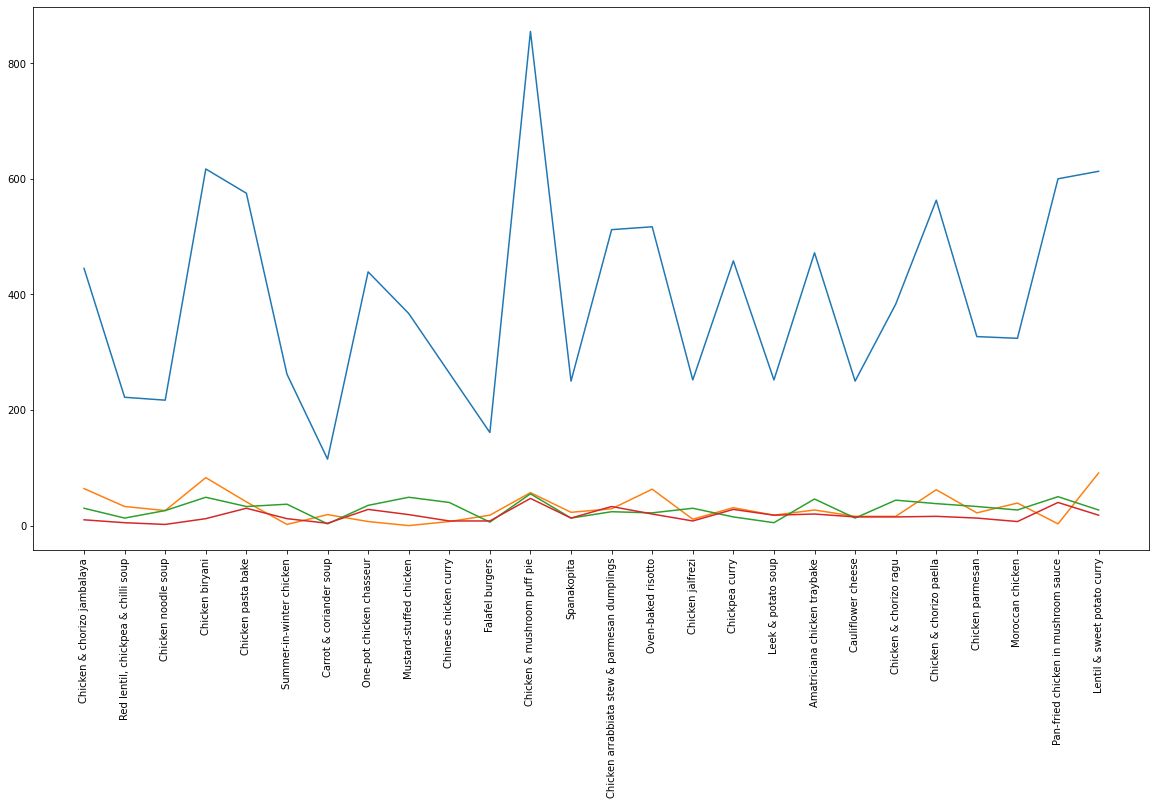

In [24]:
plt.figure(figsize=(20,10))
plt.plot('Name','kcal',data=dt)
plt.plot('Name','carbs',data=dt)
plt.plot('Name','proteins',data=dt)
plt.plot('Name','fats',data=dt)
plt.xticks(rotation=90)
plt.show()

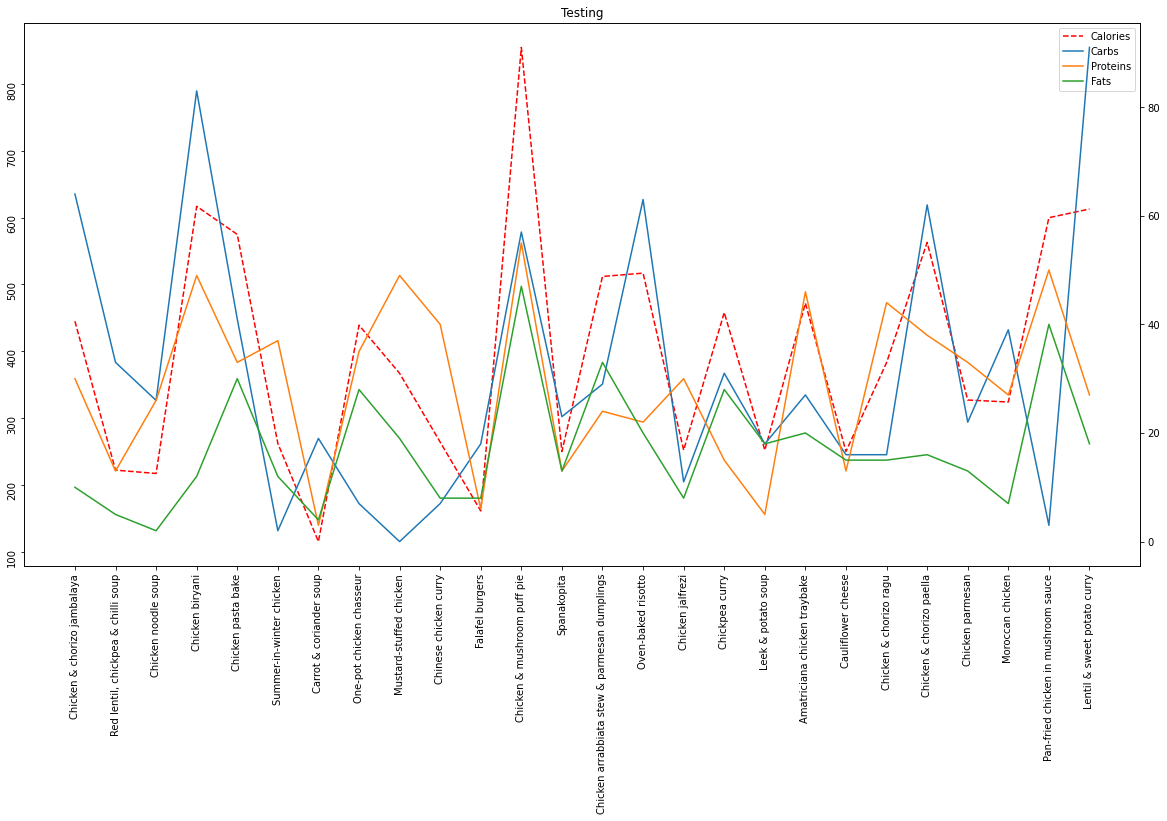

In [49]:
''' 
This code looks at plotting information on two axis using matplotlib
'''

#create a figure for the entire plot
fig, ax1 = plt.subplots(figsize=(20,10))

#assign the plot to a variable to be called later
plot1, = ax1.plot('Name','kcal',data=dt,color='red',label='Calories',linestyle='--')
ax1.tick_params(labelrotation=90)
ax1.set_title('Testing')

#create another axes copying the original one
ax2 = ax1.twinx()
plot2, = ax2.plot('Name','carbs',data=dt,label='Carbs')
plot3, = ax2.plot('Name','proteins',data=dt,label='Proteins')
plot4, = ax2.plot('Name','fats',data=dt,label='Fats')
#ax2.legend()

ax1.tick_params(labelrotation=90)
ax1.legend(handles=[plot1,plot2,plot3,plot4])

plt.show()

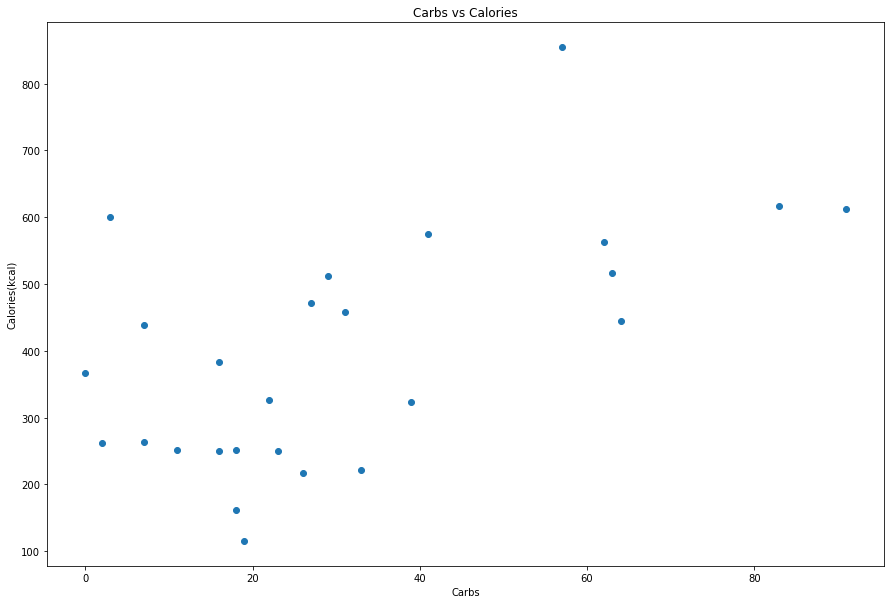

In [68]:
'''Looking at carbs versus calories'''
plt.figure(figsize=(15,10))
plt.scatter(x='carbs',y='kcal',data=dt)
plt.xlabel('Carbs')
plt.ylabel('Calories(kcal)')
plt.title('Carbs vs Calories')

plt.show()

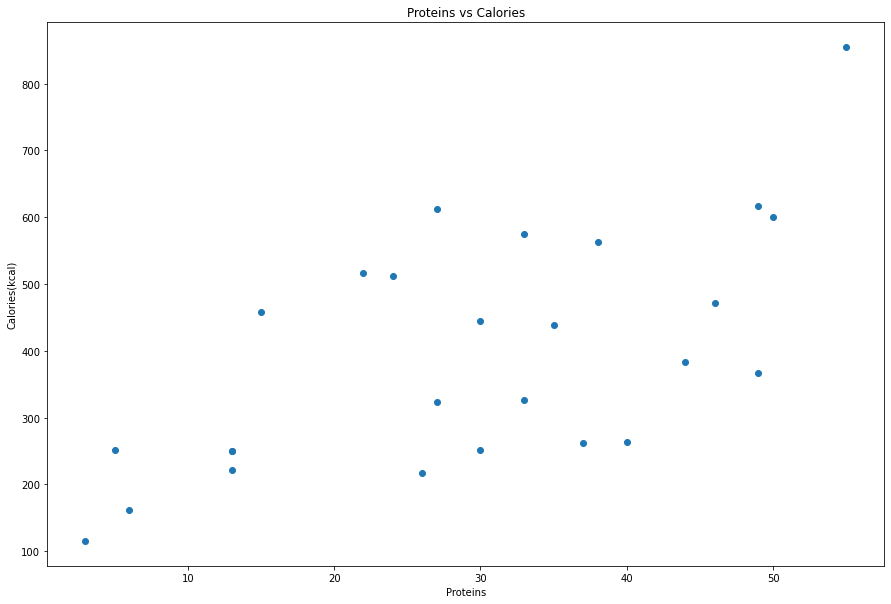

In [69]:
'''Looking at Proteins versus calories'''
plt.figure(figsize=(15,10))
plt.scatter(x='proteins',y='kcal',data=dt)
plt.xlabel('Proteins')
plt.ylabel('Calories(kcal)')
plt.title('Proteins vs Calories')

plt.show()

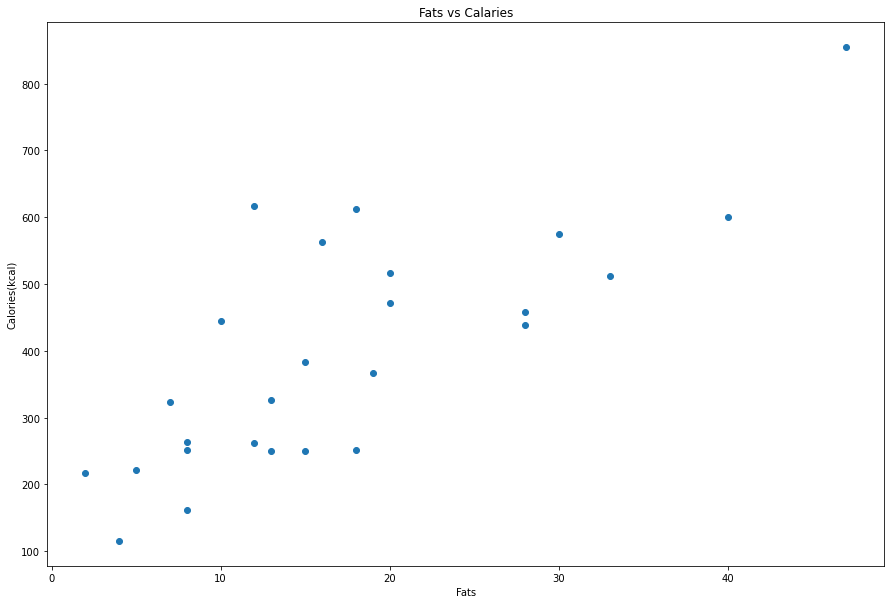

In [70]:
'''Looking at Fats versus calories'''
plt.figure(figsize=(15,10))
plt.scatter(x='fats',y='kcal',data=dt)
plt.xlabel('Fats')
plt.ylabel('Calories(kcal)')
plt.title('Fats vs Calaries')

plt.show()

### Ratings

In [32]:
rating_info = dt.value_counts('Rating').to_frame("Count")

In [33]:
rating_info.sort_index()

,Count
Rating,
4.3,1
4.5,2
4.6,3
4.7,8
4.8,10
4.9,2


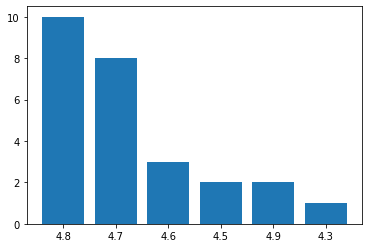

In [43]:
plt.bar(data=rating_info,x=rating_info.index,height='Count')
plt.show()